# CKG Reasoner v2 — B_Dengue_1523

Organized Colab workflow for the manuscript experiments. The diagnostic reasoner is fitted without outcome labels; ground truth is used only after partitioning for retrospective evaluation.

## 0. Reproducibility configuration

In [3]:
# Manuscript configuration
DISEASE = 'Dengue'
TARGET = 'Result'
BASELINE_K = 2
RANDOM_STATE = 42
K_RANGE = range(2, 11)
CLUSTER_VARIABLES = ["P_evidence", "r", "c", "Confidence_Score"]
BOOTSTRAP_N = 1000
WITHHOLD_FRACTIONS = [0.10, 0.25, 0.50]
SEEDS = list(range(20))

print("Disease:", DISEASE)
print("Target:", TARGET)
print("Baseline K:", BASELINE_K)
print("Baseline clustering variables:", CLUSTER_VARIABLES)

Disease: Dengue
Target: Result
Baseline K: 2
Baseline clustering variables: ['P_evidence', 'r', 'c', 'Confidence_Score']


## 1. Colab / package setup

In [4]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)


Mounted at /content/drive


In [5]:
import sys
import os
import importlib

# ============================================================
# CKG REASONER — COLAB SOURCE SETUP + VALIDATION
# ============================================================

PACKAGE_PATH = "/content/drive/MyDrive/CKG/ckg_reasoner_package_v2"
SRC_PATH = os.path.join(PACKAGE_PATH, "src")
CKG_PATH = os.path.join(SRC_PATH, "ckg_reasoner")
DATA_PATH = os.path.join(CKG_PATH, "data")

print("=" * 70)
print("CKG REASONER — COLAB SOURCE SETUP")
print("=" * 70)

print("PACKAGE_PATH :", PACKAGE_PATH)
print("SRC_PATH     :", SRC_PATH)
print("CKG_PATH     :", CKG_PATH)

# ------------------------------------------------------------
# 1. Validate package structure
# ------------------------------------------------------------

required_directories = {
    "Package directory": PACKAGE_PATH,
    "Source directory": SRC_PATH,
    "CKG package directory": CKG_PATH,
}

for label, path in required_directories.items():
    exists = os.path.isdir(path)
    print(f"{label:<24}: {'OK' if exists else 'MISSING'}")

    if not exists:
        raise FileNotFoundError(
            f"{label} not found:\n{path}"
        )


required_files = [
    "__init__.py",
    "model.py",
    "reasoning.py",
    "knowledge.py",
]

missing_files = [
    filename
    for filename in required_files
    if not os.path.isfile(os.path.join(CKG_PATH, filename))
]

if missing_files:
    raise FileNotFoundError(
        "Required CKG package files are missing:\n"
        + "\n".join(f"  - {name}" for name in missing_files)
    )

print("\nRequired core package files: OK")


# ------------------------------------------------------------
# 2. Remove previously added CKG package paths
# ------------------------------------------------------------

old_paths = [
    p for p in sys.path
    if "ckg_reasoner_package" in str(p)
]

if old_paths:
    print("\nRemoving previous CKG source paths:")
    for p in old_paths:
        print("  ", p)

sys.path = [
    p for p in sys.path
    if "ckg_reasoner_package" not in str(p)
]


# ------------------------------------------------------------
# 3. Force the selected source directory to highest priority
# ------------------------------------------------------------

sys.path.insert(0, SRC_PATH)

print("\nActive source path:")
print(" ", sys.path[0])


# ------------------------------------------------------------
# 4. Remove stale imported CKG modules
# ------------------------------------------------------------

removed_modules = []

for name in list(sys.modules):
    if name == "ckg_reasoner" or name.startswith("ckg_reasoner."):
        removed_modules.append(name)
        del sys.modules[name]

if removed_modules:
    print("\nRemoved cached CKG modules:")
    for name in sorted(removed_modules):
        print("  ", name)
else:
    print("\nNo cached CKG modules found.")

importlib.invalidate_caches()


# ------------------------------------------------------------
# 5. Display package contents before import
# ------------------------------------------------------------

print("\n=== PACKAGE CONTENTS ===")

package_files = sorted(os.listdir(CKG_PATH))

for filename in package_files[:30]:
    print("  ", filename)

if len(package_files) > 30:
    print(f"  ... and {len(package_files) - 30} more")


# ------------------------------------------------------------
# 6. Import CKG Reasoner
# ------------------------------------------------------------

import ckg_reasoner
from ckg_reasoner import CKGModel


# ------------------------------------------------------------
# 7. Verify imported package
# ------------------------------------------------------------

print("\n=== IMPORT CHECK ===")

print("Imported from:")
print(" ", ckg_reasoner.__file__)

print("\nPackage path:")
for p in ckg_reasoner.__path__:
    print(" ", p)

CKG_VERSION = getattr(
    ckg_reasoner,
    "__version__",
    "NO VERSION"
)

print("\nVersion:", CKG_VERSION)
print(
    "CKGModel available:",
    hasattr(ckg_reasoner, "CKGModel")
)
print("CKGModel:", CKGModel)


# ------------------------------------------------------------
# 8. Safety check:
#    ensure Colab did not import another installed CKG package
# ------------------------------------------------------------

imported_file = os.path.realpath(ckg_reasoner.__file__)
expected_root = os.path.realpath(SRC_PATH)

try:
    common_root = os.path.commonpath(
        [imported_file, expected_root]
    )
except ValueError:
    common_root = ""

if common_root != expected_root:
    raise RuntimeError(
        "\nWRONG CKG PACKAGE IMPORTED!\n\n"
        f"Expected package under:\n{expected_root}\n\n"
        f"But imported:\n{imported_file}"
    )

print("\nSource-path verification: PASSED")


# ------------------------------------------------------------
# 9. Check important modules
# ------------------------------------------------------------

important_modules = [
    "condition_logic.py",
    "units.py",
    "function_policy.py",
    "functions.py",
    "clinical_transformer.py",
    "mapping.py",
    "retrieval.py",
    "reporting.py",
]

print("\n=== MODULE CHECK ===")

missing_modules = []

for filename in important_modules:
    path = os.path.join(CKG_PATH, filename)
    exists = os.path.isfile(path)

    print(
        f"{filename:<30}"
        f"{'OK' if exists else 'MISSING'}"
    )

    if not exists:
        missing_modules.append(filename)


# ------------------------------------------------------------
# 10. Check bundled knowledge/data files
# ------------------------------------------------------------

print("\n=== DATA / KNOWLEDGE CHECK ===")
print("Data directory:", DATA_PATH)
print(
    "Data directory exists:",
    os.path.isdir(DATA_PATH)
)

yaml_files = []

if os.path.isdir(DATA_PATH):

    for root, dirs, files in os.walk(DATA_PATH):

        for filename in files:

            if filename.lower().endswith(
                (".yaml", ".yml")
            ):
                yaml_files.append(
                    os.path.join(root, filename)
                )

    yaml_files = sorted(yaml_files)

    print("YAML/YML files found:", len(yaml_files))

    for path in yaml_files:
        print(
            "  ",
            os.path.relpath(path, CKG_PATH)
        )

else:
    print("WARNING: bundled data directory not found.")


# ------------------------------------------------------------
# 11. Final diagnostic summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CKG REASONER SETUP COMPLETED")
print("=" * 70)

print("Source       :", SRC_PATH)
print("Imported from:", ckg_reasoner.__file__)
print("Version      :", CKG_VERSION)
print("CKGModel     : READY")

print(
    "Core files   :",
    "OK" if not missing_files else "MISSING"
)

print(
    "Extra modules:",
    "OK" if not missing_modules
    else f"{len(missing_modules)} MISSING"
)

print(
    "Knowledge YAML:",
    len(yaml_files)
)

print("=" * 70)

CKG REASONER — COLAB SOURCE SETUP
PACKAGE_PATH : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2
SRC_PATH     : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src
CKG_PATH     : /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner
Package directory       : OK
Source directory        : OK
CKG package directory   : OK

Required core package files: OK

Active source path:
  /content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src

No cached CKG modules found.

=== PACKAGE CONTENTS ===
   __init__.py
   __pycache__
   clinical_transformer.py
   condition_logic.py
   confidence.py
   config.py
   data
   evaluation.py
   explanation.py
   function_policy.py
   functions.py
   gaussian.py
   graphview.py
   hard_assignment.py
   kmeans.py
   knowledge.py
   legacy_activation.py
   mahalanobis.py
   manual_audit.py
   mapping.py
   model.py
   reasoning.py
   reporting.py
   retrieval.py
   separation.py
   uncertainty.py
   units.py
   visualization.py

=== IMPORT CHECK =

In [6]:
from ckg_reasoner import CKGModel, __version__

model = CKGModel()

print("Version:", __version__)
print(model.kb.audit())

Version: 2
{'knowledge_base_path': '/content/drive/MyDrive/CKG/ckg_reasoner_package_v2/src/ckg_reasoner/data/diseases', 'disease_graph_count': 3, 'diseases': ['Dengue Fever', 'Influenza', 'Malaria'], 'yaml_file_count': 12}


In [7]:
import ckg_reasoner
from ckg_reasoner import (
    CKGModel,
    HardAssignment,
    KMeansPartition,
    GaussianPartition,
    MahalanobisPartition
)

print("CKG Reasoner version:", ckg_reasoner.__version__)

model = CKGModel()

print("CKGModel created successfully.")

CKG Reasoner version: 2
CKGModel created successfully.


## 2. Load cohort

In [8]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/CKG/KG2_Selected_4_Datasets/C2_D4_Dengue_Hematological_1523.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nColumns:")
for col in df.columns:
    print(col)

Shape: (1523, 19)


,Gender,Age,Hemoglobin(g/dl),Neutrophils(%),Lymphocytes(%),Monocytes(%),Eosinophils(%),RBC,HCT(%),MCV(fl),MCH(pg),MCHC(g/dl),RDW-CV(%),Total Platelet Count(/cumm),MPV(fl),PDW(%),PCT(%),Total WBC count(/cumm),Result
0,Male,21,14.8,48,47,3,2,5,48.00,96.0,29.60,30.8,11.6,112000,10.70,15.40,0.120,5100,positive
1,Male,30,15.0,47,49,6,3,5,49.80,96.1,28.40,29.5,11.8,96000,10.60,15.80,0.121,4500,positive
2,Male,51,16.3,41,48,4,5,5,50.10,93.5,31.30,32.7,13.5,184000,10.40,16.40,0.130,6000,negative
3,Female,26,12.3,46,49,7,5,5,44.00,90.0,30.50,30.5,14.7,167000,8.10,17.10,0.110,5000,negative
4,Male,35,16.1,45,46,4,4,5,50.53,91.0,29.12,29.2,15.2,155000,10.52,12.34,0.150,4600,negative



Columns:
Gender
Age
Hemoglobin(g/dl)
Neutrophils(%)
Lymphocytes(%)
Monocytes(%)
Eosinophils(%)
RBC
HCT(%)
MCV(fl)
MCH(pg)
MCHC(g/dl)
RDW-CV(%)
Total Platelet Count(/cumm)
MPV(fl)
PDW(%)
PCT(%)
Total WBC count(/cumm)
Result


## 3. Map patient variables and run frozen KG reasoning

In [9]:
model.hmap(df, interactive=False)

print("\nDetected schema:")
print(model.detected_schema_)

print("\nDetected target:")
print(model.target_column_)

print("\nHeader mapping report:")
display(model.hmap_report())

Detected dataset schema: C2_D4_Dengue_Hematology_1523 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
            dataset_heading     ontology_heading
           Hemoglobin(g/dl)  HGB_hemoglobin_g_dl
             Neutrophils(%) NEU_neutrophil_count
             Lymphocytes(%) LYM_lymphocyte_count
               Monocytes(%)   MON_monocyte_count
             Eosinophils(%) EOS_eosinophil_count
                        RBC             RBC1_rbc
                     HCT(%)       HCT_hematocrit
                    MCV(fl)              MCV_mcv
                    MCH(pg)              MCH_mch
                 MCHC(g/dl)            MCHC_mchc
                  RDW-CV(%)              RDW_rdw
Total Platelet Count(/cumm)   MTP_platelet_count
                    MPV(fl)              MPV_mpv
                     PDW(%)              PDW_pdw
                     PCT(%)              PCT_pct
     Total WBC count(/cumm)              LEU_wbc
Ignored metadata/tar

,dataset_heading,ontology_heading,status,confidence,source_unit,canonical_unit,unit_status
0,id,None,ignored,1.0,None,None,not_mapped
1,Gender,None,ignored,1.0,None,None,not_mapped
2,Age,None,ignored,1.0,None,None,not_mapped
3,Hemoglobin(g/dl),HGB_hemoglobin_g_dl,schema_exact,1.0,g/dL,g/dL,canonical
4,Neutrophils(%),NEU_neutrophil_count,schema_exact,1.0,%,%,canonical
5,Lymphocytes(%),LYM_lymphocyte_count,schema_exact,1.0,%,%,canonical
6,Monocytes(%),MON_monocyte_count,schema_exact,1.0,%,%,canonical
7,Eosinophils(%),EOS_eosinophil_count,schema_exact,1.0,%,%,canonical
8,RBC,RBC1_rbc,schema_exact,1.0,million/uL,million/uL,canonical
9,HCT(%),HCT_hematocrit,schema_exact,1.0,%,%,canonical


In [10]:
model.graphfit(strategy="exhaustive")



Graph fitting completed for 1523 record(s); strategy='exhaustive'; knowledge base=3 disease graph(s).
Auto K-means completed on S0=[P_evidence, r, c, Confidence_Score] (optimal K=4; target ordering=Dengue Fever).


CKGModel(state='fitted', diseases=['Dengue Fever', 'Influenza', 'Malaria'], rows=1523)

## 4. Single-record reasoning sanity check

In [11]:
model.evidence("Dengue", row=0)
model.Continuous_reasoning("Dengue", row=0)
model.Deterministic_reasoning("Dengue", row=0)
model.Uncertainty("Dengue", row=0)
model.explain("Dengue", row=0)

{'Dengue Fever': {'patient_id': 0,
  'disease': 'Dengue Fever',
  'evidence_facts': [{'feature': 'LEU_laboratory',
    'name': 'Leukopenia',
    'observed': True,
    'observations': [{'component': 'wbc', 'value': 5100}],
    'similarity': 0.0,
    'clinical_importance': 1.0,
    'specificity': 0.85,
    'support': 0.8,
    'contradiction': 0.8,
    'positive_contribution': 0.0027559548258750052,
    'negative_contribution': 0.7911732690881602},
   {'feature': 'NEU_laboratory',
    'name': 'Neutropenia',
    'observed': True,
    'observations': [{'component': 'neutrophil_count', 'value': 48}],
    'similarity': 0.0,
    'clinical_importance': 0.7,
    'specificity': 0.7,
    'support': 0.8,
    'contradiction': 0.5,
    'positive_contribution': 0.0015887268996220617,
    'negative_contribution': 0.4944832931801001},
   {'feature': 'LYM_laboratory',
    'name': 'Lymphocytosis',
    'observed': True,
    'observations': [{'component': 'lymphocyte_count', 'value': 47}],
    'similarity':

## 5. Label-free clustering diagnostics

Elbow-recommended cluster number: 3
Silhouette-recommended cluster number: 4
Combined best cluster number: 4


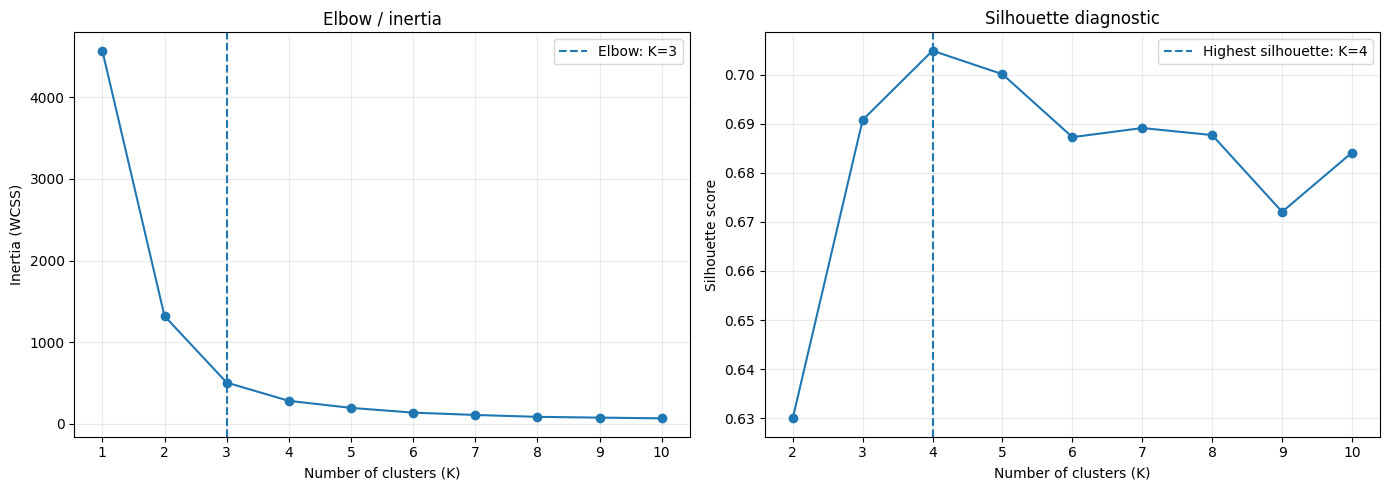

kmeans diagnostics complete. Advisory recommended n=4; choose n manually for the final fit.


,n,k,inertia,silhouette,elbow_strength,silhouette_strength,combined_score
0,1,1,4569.000000,NaN,0.000000,NaN,NaN
1,2,2,1320.161473,0.629971,0.897333,0.000000,0.448667
2,3,3,505.538667,0.690749,1.000000,0.811707,0.905854
3,4,4,282.212783,0.704847,0.909634,1.000000,0.954817
4,5,5,195.843661,0.700063,0.774557,0.936096,0.855326
5,6,6,137.840801,0.687244,0.630220,0.764905,0.697562
6,7,7,109.168293,0.689100,0.476307,0.789693,0.633000
7,8,8,85.923055,0.687664,0.320623,0.770506,0.545564
8,9,9,76.692973,0.672028,0.160364,0.561685,0.361024
9,10,10,67.783271,0.684107,0.000000,0.723007,0.361503


Elbow k: 3
Silhouette k: 4
Combined best k: 4


In [12]:
# Baseline K-means diagnostics on all four post-KG coordinates.
kdiag = model.diagnostics(
    "kmeans", positive_disease=DISEASE, min_clusters=2, max_clusters=10,
    variables=None, show=True, print_recommendations=True
)
display(kdiag)
print("Elbow k:", kdiag.attrs.get("elbow_recommended_n"))
print("Silhouette k:", kdiag.attrs.get("silhouette_recommended_n"))
print("Combined best k:", kdiag.attrs.get("best_k", kdiag.attrs.get("recommended_n")))

## 6. Pre-specified baseline partition and retrospective evaluation

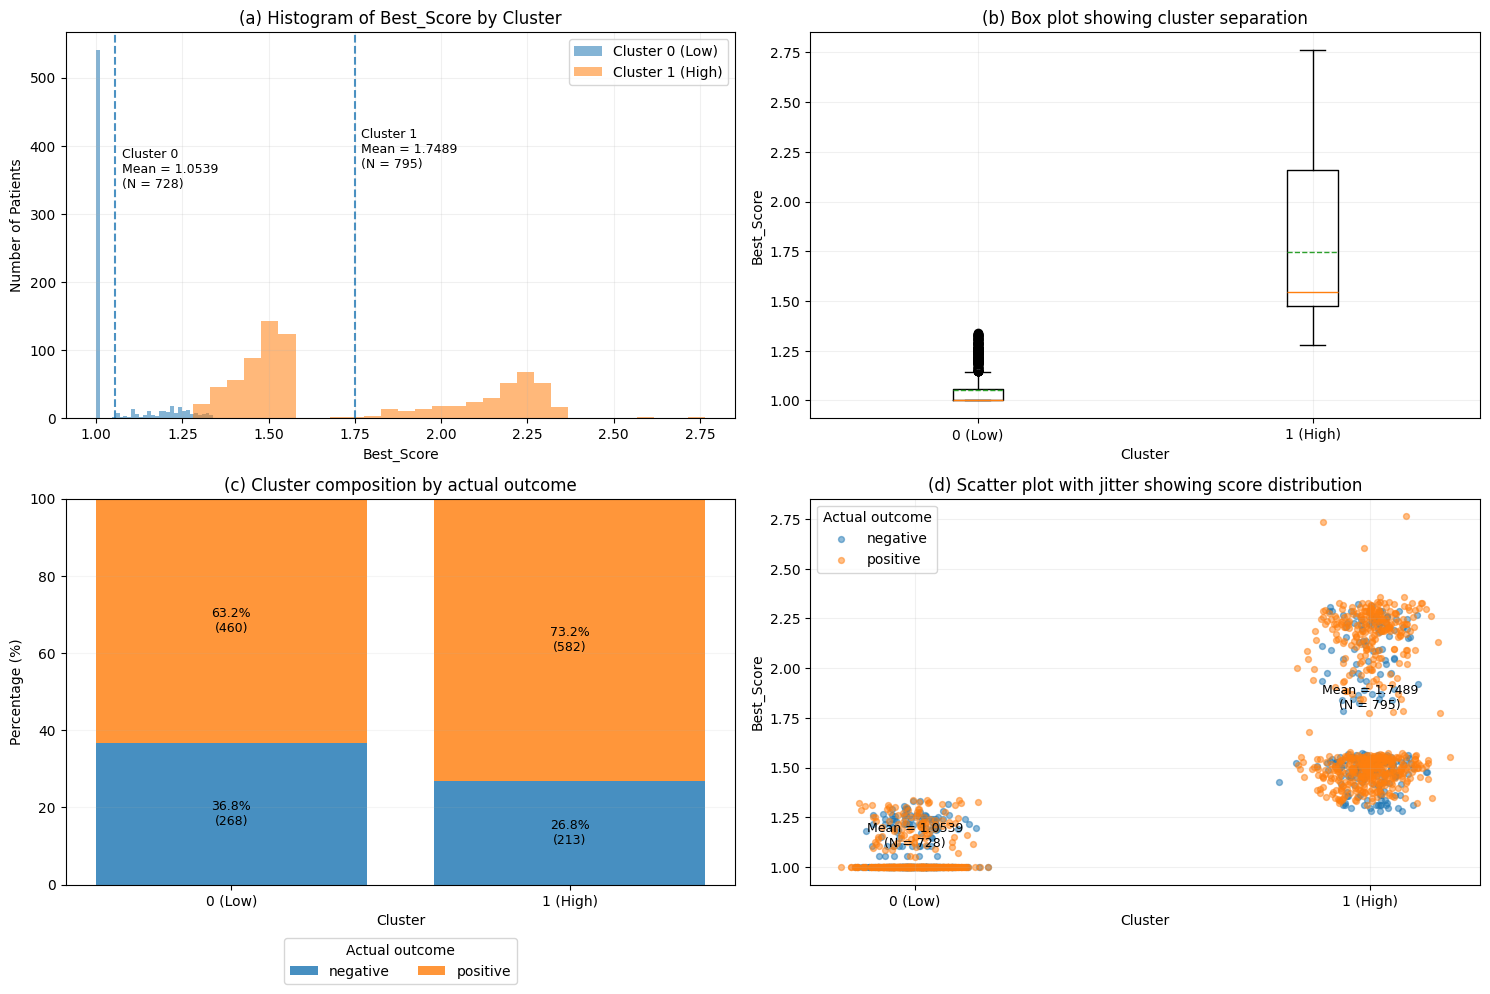

ALL-RECORD EVALUATION
{'n': 1523, 'accuracy': 0.5581089954038083, 'balanced_accuracy': np.float64(0.5578569119835914), 'precision_macro': 0.5501036699149906, 'recall_macro': 0.5578569119835914, 'f1_macro': 0.5384917059632146, 'f1_weighted': 0.5735404300911543, 'mcc': np.float64(0.10768182057016931), 'cohen_kappa': np.float64(0.10166077840716381), 'ground_truth_counts': {'positive': 1042, 'negative': 481}, 'prediction_counts': {'positive': 795, 'negative': 728}, 'labels': ['negative', 'positive'], 'confusion_matrix': array([[268, 213],
       [460, 582]]), 'binary_label_order': ['negative', 'positive'], 'tn': 268, 'fp': 213, 'fn': 460, 'tp': 582, 'sensitivity': np.float64(0.5585412667946257), 'specificity': np.float64(0.5571725571725572), 'npv': np.float64(0.36813186813186816), 'ppv': np.float64(0.7320754716981132), 'f1_positive': 0.6336418072945019, 'f1': 0.6336418072945019, 'n_total': 1523, 'n_indeterminate': 0, 'coverage': 1.0, 'abstention_rate': 0.0, 'positive_disease': 'Dengue Feve

In [13]:
from ckg_reasoner import KMeansPartition

km = model.partition(
    KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                    random_state=RANDOM_STATE, n_init=20, variables=None),
    DISEASE, show=False
)
km.visualize(y_true=model.df_[TARGET])

result_all = model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
result_selective = model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=km)
print("ALL-RECORD EVALUATION")
print(result_all)
print("\nDECIDED/SUBSET EVALUATION")
print(result_selective)

## 7. Manuscript component ablation — post-KG representation

These experiments change only the coordinates supplied to K-means. They do **not** refit the diagnostic reasoner. The first six rows correspond to the manuscript table; `No CS` is an additional exploratory check.

In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score

ABLATIONS = {
    "Full": None,  # variables=None => all four eligible coordinates
    "No P_evidence": ["r", "c", "Confidence_Score"],
    "No r": ["P_evidence", "c", "Confidence_Score"],
    "No c": ["P_evidence", "r", "Confidence_Score"],
    "P_evidence only": ["P_evidence"],
    "Profile only (r,c)": ["r", "c"],
    "No CS [exploratory]": ["P_evidence", "r", "c"],
}

def metric_value(d, *names):
    for n in names:
        if n in d: return d[n]
    return np.nan

baseline_tags = km.predictions_.astype(str)
rows=[]
partition_objects={}
for name, variables in ABLATIONS.items():
    part=model.partition(KMeansPartition(n_clusters=BASELINE_K, min_clusters=2, max_clusters=10,
                         random_state=RANDOM_STATE, n_init=20, variables=variables), DISEASE, show=False)
    partition_objects[name]=part
    allm=model.evaluate(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    selm=model.evaluate_tag(y_true=TARGET, positive_disease=DISEASE, positive_label=1, method=part)
    rows.append({
        "ablation":name, "variables":"ALL 4" if variables is None else ", ".join(variables),
        "ARI_vs_full":adjusted_rand_score(baseline_tags,part.predictions_.astype(str)),
        "accuracy_all":metric_value(allm,"accuracy"),
        "balanced_accuracy_all":metric_value(allm,"balanced_accuracy"),
        "MCC_all":metric_value(allm,"mcc","matthews_corrcoef"),
        "F1_positive_all":metric_value(allm,"f1_positive","f1"),
        "F1_positive_decided":metric_value(selm,"f1_positive","f1"),
        "coverage":metric_value(selm,"coverage"),
        "n_indeterminate":metric_value(selm,"n_indeterminate"),
    })
component_ablation=pd.DataFrame(rows)
display(component_ablation)

,ablation,variables,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,F1_positive_all,F1_positive_decided,coverage,n_indeterminate
0,Full,ALL 4,1.000000,0.558109,0.557857,0.107682,0.633642,0.633642,1.0,0
1,No P_evidence,"r, c, Confidence_Score",0.882758,0.541037,0.547620,0.088542,0.612313,0.612313,1.0,0
2,No r,"P_evidence, c, Confidence_Score",0.689671,0.561392,0.525558,0.048641,0.660224,0.660224,1.0,0
3,No c,"P_evidence, r, Confidence_Score",0.793753,0.546947,0.568168,0.127019,0.606613,0.606613,1.0,0
4,P_evidence only,P_evidence,0.634082,0.607354,0.582652,0.156690,0.693648,0.693648,1.0,0
5,"Profile only (r,c)","r, c",0.882758,0.541037,0.547620,0.088542,0.612313,0.612313,1.0,0
6,No CS [exploratory],"P_evidence, r, c",1.000000,0.558109,0.557857,0.107682,0.633642,0.633642,1.0,0


## 8. K sensitivity and 20-seed stability

In [15]:
# K sensitivity (K=2,...,10) using all four coordinates.
k_rows=[]
for kval in K_RANGE:
    p=model.partition(KMeansPartition(n_clusters=kval,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=model.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    k_rows.append({"k":kval,"accuracy":metric_value(a,"accuracy"),"balanced_accuracy":metric_value(a,"balanced_accuracy"),
                   "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
k_sensitivity=pd.DataFrame(k_rows)
display(k_sensitivity)

# Seed stability against seed-42 baseline.
seed_rows=[]
for seed in SEEDS:
    p=model.partition(KMeansPartition(n_clusters=BASELINE_K,min_clusters=2,max_clusters=10,random_state=seed,n_init=20,variables=None),DISEASE,show=False)
    s=model.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    seed_rows.append({"seed":seed,"ARI_vs_seed42":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
seed_stability=pd.DataFrame(seed_rows)
display(seed_stability)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics

,k,accuracy,balanced_accuracy,f1_positive,coverage
0,2,0.558109,0.557857,0.633642,1.000000
1,3,0.288247,0.329299,0.490811,0.597505
2,4,0.265266,0.296834,0.508671,0.544320
3,5,0.218647,0.262765,0.428777,0.479317
4,6,0.217334,0.260686,0.428777,0.478004
5,7,0.204202,0.251089,0.398148,0.460276
6,8,0.204202,0.251089,0.398148,0.460276
7,9,0.195666,0.244851,0.376013,0.448457
8,10,0.195666,0.244851,0.376013,0.448457


,seed,ARI_vs_seed42,f1_positive,coverage
0,0,1.0,0.633642,1.0
1,1,1.0,0.633642,1.0
2,2,1.0,0.633642,1.0
3,3,1.0,0.633642,1.0
4,4,1.0,0.633642,1.0
5,5,1.0,0.633642,1.0
6,6,1.0,0.633642,1.0
7,7,1.0,0.633642,1.0
8,8,1.0,0.633642,1.0
9,9,1.0,0.633642,1.0


## 9. Bootstrap uncertainty (1,000 nonparametric resamples)

This bootstraps the fixed baseline predictions; it does not refit K-means and therefore quantifies sampling uncertainty of the reported retrospective metrics.

In [16]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, matthews_corrcoef

truth=(model.df_[TARGET].astype(str).str.strip().str.lower().isin(["1","1.0","true","yes","positive","pos"])).astype(int).to_numpy()
pred_tag=km.predictions_.astype(str).to_numpy()
rng=np.random.default_rng(RANDOM_STATE)
boot=[]
for b in range(BOOTSTRAP_N):
    ix=rng.integers(0,len(truth),len(truth))
    yt=truth[ix]; pt=pred_tag[ix]
    yp=(pt=="positive").astype(int)
    decided=(pt!="indeterminate")
    row={"accuracy_all":accuracy_score(yt,yp),"coverage":decided.mean()}
    if len(np.unique(yt))>1:
        row["balanced_accuracy_all"]=balanced_accuracy_score(yt,yp)
        row["mcc_all"]=matthews_corrcoef(yt,yp)
    else:
        row["balanced_accuracy_all"]=np.nan; row["mcc_all"]=np.nan
    if decided.any(): row["f1_positive_decided"]=f1_score(yt[decided],yp[decided],zero_division=0)
    else: row["f1_positive_decided"]=np.nan
    boot.append(row)
bootstrap_df=pd.DataFrame(boot)
bootstrap_ci=bootstrap_df.quantile([0.025,0.5,0.975]).T.rename(columns={0.025:"CI_2.5%",0.5:"median",0.975:"CI_97.5%"})
display(bootstrap_ci)

,CI_2.5%,median,CI_97.5%
accuracy_all,0.532502,0.558109,0.581090
coverage,1.000000,1.000000,1.000000
balanced_accuracy_all,0.530507,0.558074,0.582495
mcc_all,0.056867,0.107628,0.152994
f1_positive_decided,0.606961,0.633749,0.657845


## 10. Reasoner-level ablations: contradiction and clinical importance

These rerun `graphfit()` after changing the encoded disease knowledge. They are intentionally separate from coordinate ablation.

In [17]:
from copy import deepcopy

def fresh_model_from_df(df_variant, knowledge_ablation=None):
    m=CKGModel()
    if knowledge_ablation is not None:
        for disease_key, refs in m.kb.reference_vectors.items():
            for _, ref in refs.items():
                if knowledge_ablation=="no_contradiction": ref["contradiction"]="None"
                elif knowledge_ablation=="importance_unity": ref["importance"]="Critical"  # encoded value 1.0
    m.hmap(df_variant.copy(),interactive=False)
    m.graphfit(strategy="exhaustive")
    return m

def run_model_partition(m, k=BASELINE_K):
    p=m.partition(KMeansPartition(n_clusters=k,min_clusters=2,max_clusters=10,random_state=RANDOM_STATE,n_init=20,variables=None),DISEASE,show=False)
    a=m.evaluate(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    s=m.evaluate_tag(y_true=TARGET,positive_disease=DISEASE,positive_label=1,method=p)
    return p,a,s

knowledge_rows=[]
for abl in ["no_contradiction","importance_unity"]:
    m2=fresh_model_from_df(df,abl)
    p,a,s=run_model_partition(m2)
    knowledge_rows.append({"ablation":abl,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
        "accuracy_all":metric_value(a,"accuracy"),"f1_positive_decided":metric_value(s,"f1_positive","f1"),"coverage":metric_value(s,"coverage")})
knowledge_ablation=pd.DataFrame(knowledge_rows)
display(knowledge_ablation)

Detected dataset schema: C2_D4_Dengue_Hematology_1523 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
            dataset_heading     ontology_heading
           Hemoglobin(g/dl)  HGB_hemoglobin_g_dl
             Neutrophils(%) NEU_neutrophil_count
             Lymphocytes(%) LYM_lymphocyte_count
               Monocytes(%)   MON_monocyte_count
             Eosinophils(%) EOS_eosinophil_count
                        RBC             RBC1_rbc
                     HCT(%)       HCT_hematocrit
                    MCV(fl)              MCV_mcv
                    MCH(pg)              MCH_mch
                 MCHC(g/dl)            MCHC_mchc
                  RDW-CV(%)              RDW_rdw
Total Platelet Count(/cumm)   MTP_platelet_count
                    MPV(fl)              MPV_mpv
                     PDW(%)              PDW_pdw
                     PCT(%)              PCT_pct
     Total WBC count(/cumm)              LEU_wbc
Ignored metadata/tar

,ablation,ARI_vs_full,accuracy_all,f1_positive_decided,coverage
0,no_contradiction,0.984293,0.558109,0.634835,1.0
1,importance_unity,0.968711,0.555483,0.633062,1.0


## 11. Evidence-gate parameter sensitivity

One parameter family is varied at a time around the frozen baseline (α=0.05, β=10, γ=0.85). This is a controlled runtime patch for sensitivity analysis only; it does **not** modify the installed package files.

In [18]:
import math, contextlib
import ckg_reasoner.functions as ckg_functions
import ckg_reasoner.reasoning as ckg_reasoning

@contextlib.contextmanager
def temporary_gate(alpha=0.05,beta=10.0,gamma=0.85):
    old_fun=ckg_functions.manuscript_evidence_contributions
    old_reason=ckg_reasoning.manuscript_evidence_contributions
    def contrib(*,information_gate,diagnostic_role,importance,support,contradiction):
        def fgate(x):
            x=float(np.clip(x,0,1)); return 1.0/(1.0+alpha*math.exp(-beta*(x-gamma)))
        ig=float(np.clip(information_gate,0,1))
        return (fgate(ig)*max(float(diagnostic_role),0.0)*float(importance)*max(float(support),0.0),
                fgate(1.0-ig)*abs(float(contradiction)))
    ckg_functions.manuscript_evidence_contributions=contrib
    ckg_reasoning.manuscript_evidence_contributions=contrib
    try: yield
    finally:
        ckg_functions.manuscript_evidence_contributions=old_fun
        ckg_reasoning.manuscript_evidence_contributions=old_reason

gate_settings=[("baseline",0.05,10,0.85)]
gate_settings += [(f"alpha={x}",x,10,0.85) for x in [0.025,0.10]]
gate_settings += [(f"beta={x}",0.05,x,0.85) for x in [5,20]]
gate_settings += [(f"gamma={x}",0.05,10,x) for x in [0.75,0.95]]
gate_rows=[]
for name,a,b,g in gate_settings:
    with temporary_gate(a,b,g):
        mg=fresh_model_from_df(df)
        p,am,sm=run_model_partition(mg)
    gate_rows.append({"setting":name,"alpha":a,"beta":b,"gamma":g,"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                      "f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
gate_sensitivity=pd.DataFrame(gate_rows)
display(gate_sensitivity)

Detected dataset schema: C2_D4_Dengue_Hematology_1523 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
            dataset_heading     ontology_heading
           Hemoglobin(g/dl)  HGB_hemoglobin_g_dl
             Neutrophils(%) NEU_neutrophil_count
             Lymphocytes(%) LYM_lymphocyte_count
               Monocytes(%)   MON_monocyte_count
             Eosinophils(%) EOS_eosinophil_count
                        RBC             RBC1_rbc
                     HCT(%)       HCT_hematocrit
                    MCV(fl)              MCV_mcv
                    MCH(pg)              MCH_mch
                 MCHC(g/dl)            MCHC_mchc
                  RDW-CV(%)              RDW_rdw
Total Platelet Count(/cumm)   MTP_platelet_count
                    MPV(fl)              MPV_mpv
                     PDW(%)              PDW_pdw
                     PCT(%)              PCT_pct
     Total WBC count(/cumm)              LEU_wbc
Ignored metadata/tar

,setting,alpha,beta,gamma,ARI_vs_full,f1_positive_decided,coverage
0,baseline,0.050,10,0.85,1.000000,0.633642,1.0
1,alpha=0.025,0.025,10,0.85,1.000000,0.633642,1.0
2,alpha=0.1,0.100,10,0.85,1.000000,0.633642,1.0
3,beta=5,0.050,5,0.85,0.971299,0.627601,1.0
4,beta=20,0.050,20,0.85,1.000000,0.633642,1.0
5,gamma=0.75,0.050,10,0.75,1.000000,0.633642,1.0
6,gamma=0.95,0.050,10,0.95,0.997374,0.632898,1.0


## 12. Controlled random evidence withholding

A fixed random seed masks 10%, 25%, and 50% of observed non-target patient fields and reruns the entire reasoner without refitting ontology weights. Adjust `PROTECTED_COLUMNS` if your local dataset contains additional administrative/non-evidence fields.

In [19]:
PROTECTED_COLUMNS={TARGET,"id","ID","Record_ID","record_id"}
evidence_cols=[c for c in df.columns if c not in PROTECTED_COLUMNS]
withhold_rows=[]
for frac in WITHHOLD_FRACTIONS:
    dfx=df.copy(); rng=np.random.default_rng(RANDOM_STATE+int(frac*100))
    vals=dfx[evidence_cols]
    observed=vals.notna().to_numpy(); draw=rng.random(observed.shape)<frac
    mask=observed & draw
    dfx.loc[:,evidence_cols]=vals.mask(mask)
    mw=fresh_model_from_df(dfx)
    p,am,sm=run_model_partition(mw)
    withhold_rows.append({"withheld_fraction":frac,"actually_masked":int(mask.sum()),"ARI_vs_full":adjusted_rand_score(baseline_tags,p.predictions_.astype(str)),
                          "accuracy_all":metric_value(am,"accuracy"),"balanced_accuracy_all":metric_value(am,"balanced_accuracy"),
                          "MCC_all":metric_value(am,"mcc","matthews_corrcoef"),"f1_positive_decided":metric_value(sm,"f1_positive","f1"),"coverage":metric_value(sm,"coverage")})
evidence_withholding=pd.DataFrame(withhold_rows)
display(evidence_withholding)

/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[21. nan 51. ... nan 49. 49.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan 47. 41. ... 46. 41. 41.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[47. 49. 48. ... 46. 49. 44.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: 

Detected dataset schema: C2_D4_Dengue_Hematology_1523 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
            dataset_heading     ontology_heading
           Hemoglobin(g/dl)  HGB_hemoglobin_g_dl
             Neutrophils(%) NEU_neutrophil_count
             Lymphocytes(%) LYM_lymphocyte_count
               Monocytes(%)   MON_monocyte_count
             Eosinophils(%) EOS_eosinophil_count
                        RBC             RBC1_rbc
                     HCT(%)       HCT_hematocrit
                    MCV(fl)              MCV_mcv
                    MCH(pg)              MCH_mch
                 MCHC(g/dl)            MCHC_mchc
                  RDW-CV(%)              RDW_rdw
Total Platelet Count(/cumm)   MTP_platelet_count
                    MPV(fl)              MPV_mpv
                     PDW(%)              PDW_pdw
                     PCT(%)              PCT_pct
     Total WBC count(/cumm)              LEU_wbc
Ignored metadata/tar

/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan 30. 51. ... nan 49. 49.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[48. 47. nan ... nan 41. nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[47. 49. 48. ... 46. nan nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: 

Detected dataset schema: C2_D4_Dengue_Hematology_1523 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
            dataset_heading     ontology_heading
           Hemoglobin(g/dl)  HGB_hemoglobin_g_dl
             Neutrophils(%) NEU_neutrophil_count
             Lymphocytes(%) LYM_lymphocyte_count
               Monocytes(%)   MON_monocyte_count
             Eosinophils(%) EOS_eosinophil_count
                        RBC             RBC1_rbc
                     HCT(%)       HCT_hematocrit
                    MCV(fl)              MCV_mcv
                    MCH(pg)              MCH_mch
                 MCHC(g/dl)            MCHC_mchc
                  RDW-CV(%)              RDW_rdw
Total Platelet Count(/cumm)   MTP_platelet_count
                    MPV(fl)              MPV_mpv
                     PDW(%)              PDW_pdw
                     PCT(%)              PCT_pct
     Total WBC count(/cumm)              LEU_wbc
Ignored metadata/tar

/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan nan 51. ... nan 49. 49.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan 47. nan ... 46. 41. nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan 49. 48. ... 46. nan nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dfx.loc[:,evidence_cols]=vals.mask(mask)
/tmp/ipykernel_1209/3971866365.py:9: FutureWarning: 

Detected dataset schema: C2_D4_Dengue_Hematology_1523 (confidence=1.00)
Successful matches found: 16 dataset headings mapped to ontology headings.
            dataset_heading     ontology_heading
           Hemoglobin(g/dl)  HGB_hemoglobin_g_dl
             Neutrophils(%) NEU_neutrophil_count
             Lymphocytes(%) LYM_lymphocyte_count
               Monocytes(%)   MON_monocyte_count
             Eosinophils(%) EOS_eosinophil_count
                        RBC             RBC1_rbc
                     HCT(%)       HCT_hematocrit
                    MCV(fl)              MCV_mcv
                    MCH(pg)              MCH_mch
                 MCHC(g/dl)            MCHC_mchc
                  RDW-CV(%)              RDW_rdw
Total Platelet Count(/cumm)   MTP_platelet_count
                    MPV(fl)              MPV_mpv
                     PDW(%)              PDW_pdw
                     PCT(%)              PCT_pct
     Total WBC count(/cumm)              LEU_wbc
Ignored metadata/tar

,withheld_fraction,actually_masked,ARI_vs_full,accuracy_all,balanced_accuracy_all,MCC_all,f1_positive_decided,coverage
0,0.10,2730,0.570866,0.538411,0.526672,0.049766,0.623460,1.0
1,0.25,6894,0.039864,0.645437,0.510865,0.029970,0.771767,1.0
2,0.50,13854,0.045289,0.573867,0.502774,0.005597,0.690805,1.0


## 13. Export manuscript experiment tables

In [20]:
from pathlib import Path
RESULT_DIR=Path("/content/drive/MyDrive/CKG/Results")
RESULT_DIR.mkdir(parents=True,exist_ok=True)
OUT=RESULT_DIR/'B_Dengue_1523'
OUT.mkdir(parents=True,exist_ok=True)
component_ablation.to_csv(OUT/"component_ablation.csv",index=False)
k_sensitivity.to_csv(OUT/"k_sensitivity.csv",index=False)
seed_stability.to_csv(OUT/"seed_stability.csv",index=False)
bootstrap_ci.to_csv(OUT/"bootstrap_95CI.csv")
knowledge_ablation.to_csv(OUT/"knowledge_ablation.csv",index=False)
gate_sensitivity.to_csv(OUT/"gate_sensitivity.csv",index=False)
evidence_withholding.to_csv(OUT/"evidence_withholding.csv",index=False)
print("Saved manuscript experiment tables to:",OUT)

Saved manuscript experiment tables to: /content/drive/MyDrive/CKG/Results/B_Dengue_1523


## 14. Original explainability / FOL / output cells (preserved)

In [21]:
# ------------------------------------------------------------
# 2. Run both FOL outputs for every record
# ------------------------------------------------------------

for idx in range(len(model.df_)):

    model.explain(
        "Dengue",
        row=idx,
        format="fol"
    )

    model.explainable_layer(
        "Dengue",
        row=idx,
        format="report"
    )

print("FOL and explanation layers completed.")

FOL and explanation layers completed.


In [22]:
result_all = model.evaluate(
    y_true="Result",
    positive_disease="Dengue",
    positive_label=1,
    method=km
)

In [23]:
result_selective = model.evaluate_tag(
    y_true="Result",
    positive_disease="Dengue",
    positive_label=1,
    method=km
)

In [24]:
!pip install -q XlsxWriter
output_path = "/content/drive/MyDrive/CKG/Results/CKG_KMeans_outputFOL_1523.xlsx"
model.output(
    output_path,
    #"CKG_output.xlsx",
    positive_disease="Dengue",
    method=km
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 1.5 MB/s eta 0:00:00
Output written: /content/drive/MyDrive/CKG/Results/CKG_KMeans_outputFOL_1523.xlsx (method=kmeans); mismatch rows are yellow when actual outcome is available.


PosixPath('/content/drive/MyDrive/CKG/Results/CKG_KMeans_outputFOL_1523.xlsx')

In [25]:
# ============================================================
# K-MEANS EVALUATION
# ============================================================

result_all = model.evaluate(
    y_true="Result",
    positive_disease="Dengue",
    positive_label=1,
    method=km
)

result_selective = model.evaluate_tag(
    y_true="Result",
    positive_disease="Dengue",
    positive_label=1,
    method=km
)

print("\n" + "=" * 70)
print("ALL-RECORD EVALUATION")
print("=" * 70)

for metric, value in result_all.items():
    print(f"{metric}: {value}")

print("\n" + "=" * 70)
print("SELECTIVE EVALUATION")
print("=" * 70)

for metric, value in result_selective.items():
    print(f"{metric}: {value}")


ALL-RECORD EVALUATION
n: 1523
accuracy: 0.5581089954038083
balanced_accuracy: 0.5578569119835914
precision_macro: 0.5501036699149906
recall_macro: 0.5578569119835914
f1_macro: 0.5384917059632146
f1_weighted: 0.5735404300911543
mcc: 0.10768182057016931
cohen_kappa: 0.10166077840716381
ground_truth_counts: {'positive': 1042, 'negative': 481}
prediction_counts: {'positive': 795, 'negative': 728}
labels: ['negative', 'positive']
confusion_matrix: [[268 213]
 [460 582]]
binary_label_order: ['negative', 'positive']
tn: 268
fp: 213
fn: 460
tp: 582
sensitivity: 0.5585412667946257
specificity: 0.5571725571725572
npv: 0.36813186813186816
ppv: 0.7320754716981132
f1_positive: 0.6336418072945019
f1: 0.6336418072945019
n_total: 1523
n_indeterminate: 0
coverage: 1.0
abstention_rate: 0.0
positive_disease: Dengue Fever
tag_method: kmeans
evaluation_mode: all records; indeterminate retained as a third predicted label

SELECTIVE EVALUATION
n: 1523
accuracy: 0.5581089954038083
balanced_accuracy: 0.557856

In [26]:
record_id = 3

idx = model.df_.index[model.df_["id"] == record_id][0]

print("Record ID:", record_id)
print("Row:", idx)

# Score / evidence
print("\n=== SCORE ===")
print(model.evidence("Dengue", row=idx))

# FOL
print("\n=== FOL ===")
print(model.explain("Dengue", row=idx, format="fol"))

Record ID: 3
Row: 2

=== SCORE ===
{'Dengue Fever':            feature                           name  clinical_importance  \
0   LEU_laboratory                     Leukopenia                 1.00   
1   NEU_laboratory                    Neutropenia                 0.70   
2   LYM_laboratory                  Lymphocytosis                 0.50   
3   MTP_laboratory          Mild Thrombocytopenia                 1.00   
4   MON_laboratory                    Monocytosis                 0.25   
..             ...                            ...                  ...   
62    MYC_severity                    Myocarditis                 1.00   
63    RFL_severity            Respiratory Failure                 1.00   
64    STP_severity        Severe Thrombocytopenia                 1.00   
65    SLW_severity              Severe Leukopenia                 0.70   
66    EXH_severity  Extremely Elevated Hematocrit                 1.00   

    diagnostic_role  patient_activation  support  contradic

In [27]:
record_id = 3
disease = "Dengue"

idx = model.df_.index[model.df_["id"] == record_id][0]

print("Record ID:", record_id, "| Row:", idx)

print("\n=== EVIDENCE / DISEASE SCORE / SIMILARITY ===")
print(model.evidence(disease, row=idx))

print("\n=== CONTINUOUS REASONING ===")
print(model.Continuous_reasoning(disease, row=idx))

print("\n=== DETERMINISTIC REASONING ===")
print(model.Deterministic_reasoning(disease, row=idx))

print("\n=== UNCERTAINTY ===")
print(model.Uncertainty(disease, row=idx))

print("\n=== FOL ===")
print(model.explain(disease, row=idx, format="fol"))

Record ID: 3 | Row: 2

=== EVIDENCE / DISEASE SCORE / SIMILARITY ===
{'Dengue Fever':            feature                           name  clinical_importance  \
0   LEU_laboratory                     Leukopenia                 1.00   
1   NEU_laboratory                    Neutropenia                 0.70   
2   LYM_laboratory                  Lymphocytosis                 0.50   
3   MTP_laboratory          Mild Thrombocytopenia                 1.00   
4   MON_laboratory                    Monocytosis                 0.25   
..             ...                            ...                  ...   
62    MYC_severity                    Myocarditis                 1.00   
63    RFL_severity            Respiratory Failure                 1.00   
64    STP_severity        Severe Thrombocytopenia                 1.00   
65    SLW_severity              Severe Leukopenia                 0.70   
66    EXH_severity  Extremely Elevated Hematocrit                 1.00   

    diagnostic_role  pati

In [28]:
scores = model.disease_scores()
print(scores)
row_scores = scores.iloc[0].sort_values(ascending=False)
print(row_scores)

for rank, (disease, score) in enumerate(row_scores.items(), start=1):
    print(f"Rank {rank}: {disease} = {score:.6f}")

        Dengue Fever   Malaria  Influenza
row_id                                   
0           0.506688  0.004098   0.004098
1           0.745167  0.004098   0.004098
2           0.333333  0.004098   0.004098
3           0.333333  0.342799   0.004098
4           0.454840  0.004098   0.004098
...              ...       ...        ...
1518        0.517439  0.004098   0.004098
1519        0.333333  0.064178   0.004098
1520        0.501807  0.061943   0.004098
1521        0.333333  0.323953   0.004098
1522        0.333333  0.323953   0.004098

[1523 rows x 3 columns]
Dengue Fever    0.506688
Malaria         0.004098
Influenza       0.004098
Name: 0, dtype: float64
Rank 1: Dengue Fever = 0.506688
Rank 2: Malaria = 0.004098
Rank 3: Influenza = 0.004098
